### Plotting the photon and neutrino evolution following the BBN-simple paper


For more info on what are the formulae used and what was the process of this, refer to the research diary

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import special as sps
import pandas as pd

In [52]:
# Defining them constants 

## Few QOL definitions ##

pi = np.pi

def exp(x):
    return np.exp(x)

def zeta(x):
    return sps.zeta(x)

def delta(x, y):
    return 1 if x == y else 0


## Masses ##
# me = 0.510998 # Mass of electron in [MeV/c^2]
# mp = 938.27208943 # Mass of proton in [MeV/c^2]
# mn = 939.56542194 # Mass of neutron in [MeV/c^2]

me = 0.510998 # Mass of electron in [MeV/c^2]
mp = 938.272013 # Mass of proton in [MeV/c^2]
mn = 939.565346 # Mass of neutron in [MeV/c^2]
md = 1875.612793 # Mass of Deuterium in [MeV/c^2]
mt = 2808.920906 # Mass of Tritium in [MeV/c^2]
m3 = 2808.391383 # Mass of Helium-3 in [MeV/c^2]
m4 = 3727.379109 # Mass of Helium-4 (Alpha) in [MeV/c^2]
mli6 = 5603.05141 # Mass of Lithium-6 in [MeV/c^2]
mli7 = 6533.833166 # Mass of Lithium-7 in [MeV/c^2]
mbe7 = 6534.184060 # Mass of Beryllium-7 in [MeV/c^2]

amu = 931.494003 # AMU in MeV

Q = mn - mp # in [MeV/c^2]


## Energies ##
Bd = 2.224 # Binding Energy of Deuterium in [MeV]
Bt = 8.50 # Binding Energy of Tritium in [MeV]
B3 = 7.718 # Binding Energy of Helium-3 in [MeV]
B4 = 28.295 # Binding Energy of Helium-4 (Alpha) in [MeV]
Bli7 = 39.2 # Binding Energy of Lithum-7 in [MeV]
Bbe7=37.6 # Binding Energy of Beryllium-7 in [MeV]


## Elements ## 
Deut = {"m": md, "Z": 1, "A": 2, "s": 1, "B": Bd}
Trit = {"m": mt, "Z": 1, "A": 3, "s": 1/2, "B": Bt}
He3 = {"m": m3, "Z": 2, "A": 3, "s": 1/2, "B": B3}
He4 = {"m": m4, "Z": 2, "A": 4, "s": 0, "B": B4}
Li7 = {"m": mli7, "Z": 3, "A": 7, "s": 3/2, "B": Bli7}
Be7 = {"m": mbe7, "Z": 4, "A": 7, "s": 3/2, "B": Bbe7}


## General Physical Units ##
G = 6.67e-45 # Gravitational Constant [MeV^-2] 
c = 2.99e10 # Speed of Light [cm/s]
kB = 8.617e-11 # Boltzmann Constant [MeV/Kelvin]
hbar = 6.582e-22 # Reduced Planck constant h/2pi [MeV s]
NA = 6.022e23 # Avogadro's number [# molecules/mole]


## Free Parameters ##
Neff = 3.046 # Number of neutrino flavors [unitless]
tau_n = 880 # Average lifetime of a neutron before decay [s]
eta0 = 6.12e-10 # The present day ratio of baryons to photons [unitless, number density]
η0 = 6.12e-10 # The present day ratio of baryons to photons [unitless, number density]
h = 3.3683e4 * η0 # h is the baryon density constant from Kawano; it dictates how rhob evolves.

## Some useful conversions ##

def MeVtoK(T):
    'Converts T in MeV to T9'
    eV = 1/(8.619e-5) # 1 eV/kB to Kelvin
    MeV = eV*1e6 # Converting MeV to eV/kB
    K = MeV # Converting to Kelvin
    return K*T

def K9toMeV(T):
    'Converts T9 to T in MeV.'
    
    K = 8.619e-5 # 1 Kelvin to eV/kB
    K9 = K*1e9 # 10^9 Kelvin in eV/kB
    MeV = K9/1e6 # 10^9 Kelvin in MeV/kB
    return MeV*T

def MeVtoK9(T):
    'Converts T in MeV to T9'
    eV = 1/(8.619e-5) # 1 eV/kB to Kelvin
    MeV = eV*1e6 # Converting MeV to eV/kB
    K9 = MeV/1e9 # Converting Kelvin to 10^9 Kelvin
    return K9*T

Later need to replace these constants with the ones directly from scipy

In [53]:
# Defining the gaussian-laguerre quadrature integrator 

def gl_integrator(func):

    n = 64 
    roots, weights = sps.roots_laguerre(n)

    integrand = func(roots) * exp(roots) 

    integral = np.dot(integrand, weights)

    return integral


In [54]:
# Defining the functions that return the energy densities and pressure for different components of the early universe

def photon(T): 

    '''
    Returns the photon energy density, pressure 
    and the derivative of the energy density with 
    respect to temperature (evaluated at that temperature)
    at a given temperature (in MeV)
    
    '''

    # energy/mass density
    rho_gamma = (pi**2)/15 * T**4 

    # pressure 
    P_gamma = (1/3) * rho_gamma

    # drho_gamma/dT 
    drhog_dT = (4/T) * rho_gamma

    return rho_gamma, P_gamma, drhog_dT


def electron_positron(T): 
    
    '''
    Returns the electrons/positron energy/mass density, pressure 
    and the derivative of the energy density with 
    respect to temperature (evaluated at that temperature)
    at a given temperature (in MeV)
    
    '''

    # Defining the mass/energy density function's integrand

    def rho_e_integrand(x):

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand = (x**2 * dist) / (exp(dist) + 1)
        return integrand

    # Integrating the integrand and multiplying with the constants 
    rho_e = (2 / pi**2) * T**4 * gl_integrator(rho_e_integrand)

    

    # Defining the pressure function's integrand

    def P_e_integrand(x):

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand = x**4 / (dist * (exp(dist) + 1))
        return integrand 
    
    # Integrating the integrand and multiplying with the constants 
    P_e = (2 / (3 * pi**2)) * T**4 * gl_integrator(P_e_integrand)



    # Defining the drho/dT function's integrand

    def drho_dT_integrand(x): 

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand =  (x**2 * dist**2) / (exp(dist) + 1) * exp(dist) / (exp(dist) + 1)   # wrote in split format to prevent overflow issue
        return integrand 

    # Integrating the integrand and multiplying with the constants 
    drhoe_dT = (2 / pi**2) * T**3 * gl_integrator(drho_dT_integrand)

    return rho_e, P_e, drhoe_dT



def neutrino(Tnu):
    '''
    Returns the energy/mass density and pressure for the 
    neutrinos at a given temperature (in MeV)
    
    ''' 

    Neff = 3.046

    # energy density
    rhoneutrino =7/8*pi**2/15 *Neff* Tnu**4

    # pressure
    Pneutrino = rhoneutrino/3

    return rhoneutrino, Pneutrino


$$ \frac{d T}{d t} = - 3 H (\rho + P) \left( \frac{d \rho}{d T} \right)^{-1} $$

$$ \Rightarrow \frac{d t}{d T} = - \frac{1}{3 H (\rho + P)}  \left( \frac{d \rho}{d T} \right) $$

$$ \frac{d T_\nu}{d T} = \frac{T_\nu}{3 (\rho + P)} \frac{d \rho}{d T} $$

In [55]:
# Obtaining the time as a function of the temperature 

'''
We are taking this approach, where we find the age of the universe as a function of temperature instead of 
finding the temperature as the age of universe, because all our previously defined quantities are a direct function 
of the temperature (not time). 

So it would be better to take temperature as the independent quantity instead of time, and instead 
find the age of the universe as a function of time. 

Additionally we also find the neutrino temperature as a function of the photon temperature. Together we can calculate 
the relationship between the temperatures with time. 

'''


def T_dependence(T, state): 

    t, Tnu = state

    rhoe = electron_positron(T)[0]
    rhonu = neutrino(Tnu)[0]
    rhog = photon(T)[0]

    Pe = electron_positron(T)[1]
    Pnu = neutrino(Tnu)[1]
    Pg = photon(T)[1]

    drhoe_dT = electron_positron(T)[2]
    drhog_dT = photon(T)[2]
    
    H = np.sqrt(rhoe + rhonu + rhog) * np.sqrt(8*pi*G/3)/hbar

    rho_rad = rhog + rhoe
    P_rad = Pg + Pe
    drho_dT = drhoe_dT + drhog_dT

    # rho_rad = rhog + rhoe + rhonu
    # P_rad = Pg + Pe + Pnu
    # drho_dT = drhoe_dT + drhog_dT + 4*rhonu/T


    dt_dT = - (3 * H * (rho_rad + P_rad))**(-1) * drho_dT 

    dTnu_dT = Tnu / (3 * (rho_rad + P_rad)) * drho_dT

    return [dt_dT, dTnu_dT]

In [56]:
# Using the solve_ivp functionality to obtain the solutions for the DE 

Ti = 1e1   # MeV
Tf = 1e-3  # MeV
n =  1024
T = np.geomspace(Ti,Tf,n)  # MeV
T9 = MeVtoK9(T) 

T_dependence_solution = sp.integrate.solve_ivp(fun = T_dependence, t_span = T[[0,-1]], y0 = [0, Ti], t_eval = T)
t = T_dependence_solution.y[0]
Tnu = T_dependence_solution.y[1]

Testing the formula obtained from Weinberg for the neutrino temperature

In [57]:
# Defining the neutrino temperature obtained from Weinberg's relation

def Tnu_weinberg_formula(T):    # input the photon tempearture in MeV 

    y = me / T 

    def S_integrand(x):

        dist = np.sqrt(x**2 + y**2)
        
        return 45/(2 * pi**4) * (x**2)/(exp(dist) + 1) * ( dist + x**2 / (3 * dist) )  
    
    S_integrated = gl_integrator(S_integrand)

    return T * ( (4/11) * (1 + S_integrated) )**(1/3)

# Calculate the neutrino temperature using the Weinberg formula

Tnu_weinberg = np.array([Tnu_weinberg_formula(temp) for temp in T])

In [58]:
# Since we have T(t), Tnu(t) or t(T), Tnu(T) 
# i.e. the temperatures are a either a function of time or 
# the neutrino temperature and time are a function of the gamma temperature 

# We can instead define them all inside a dictionary which would make it easy to access them later on 
# Instead of using indices to access them, we can just get their direct values instead, when we want to access individual values

func_of_t = {}  # T and Tnu (in that order) as a function of time

func_of_T = {}  # t and Tnu (in that order) as a function of time


for i in range(len(T)): 

    func_of_t.update({t[i]: [T[i], Tnu[i]]})

    func_of_T.update({T[i]: [t[i], Tnu[i]]})

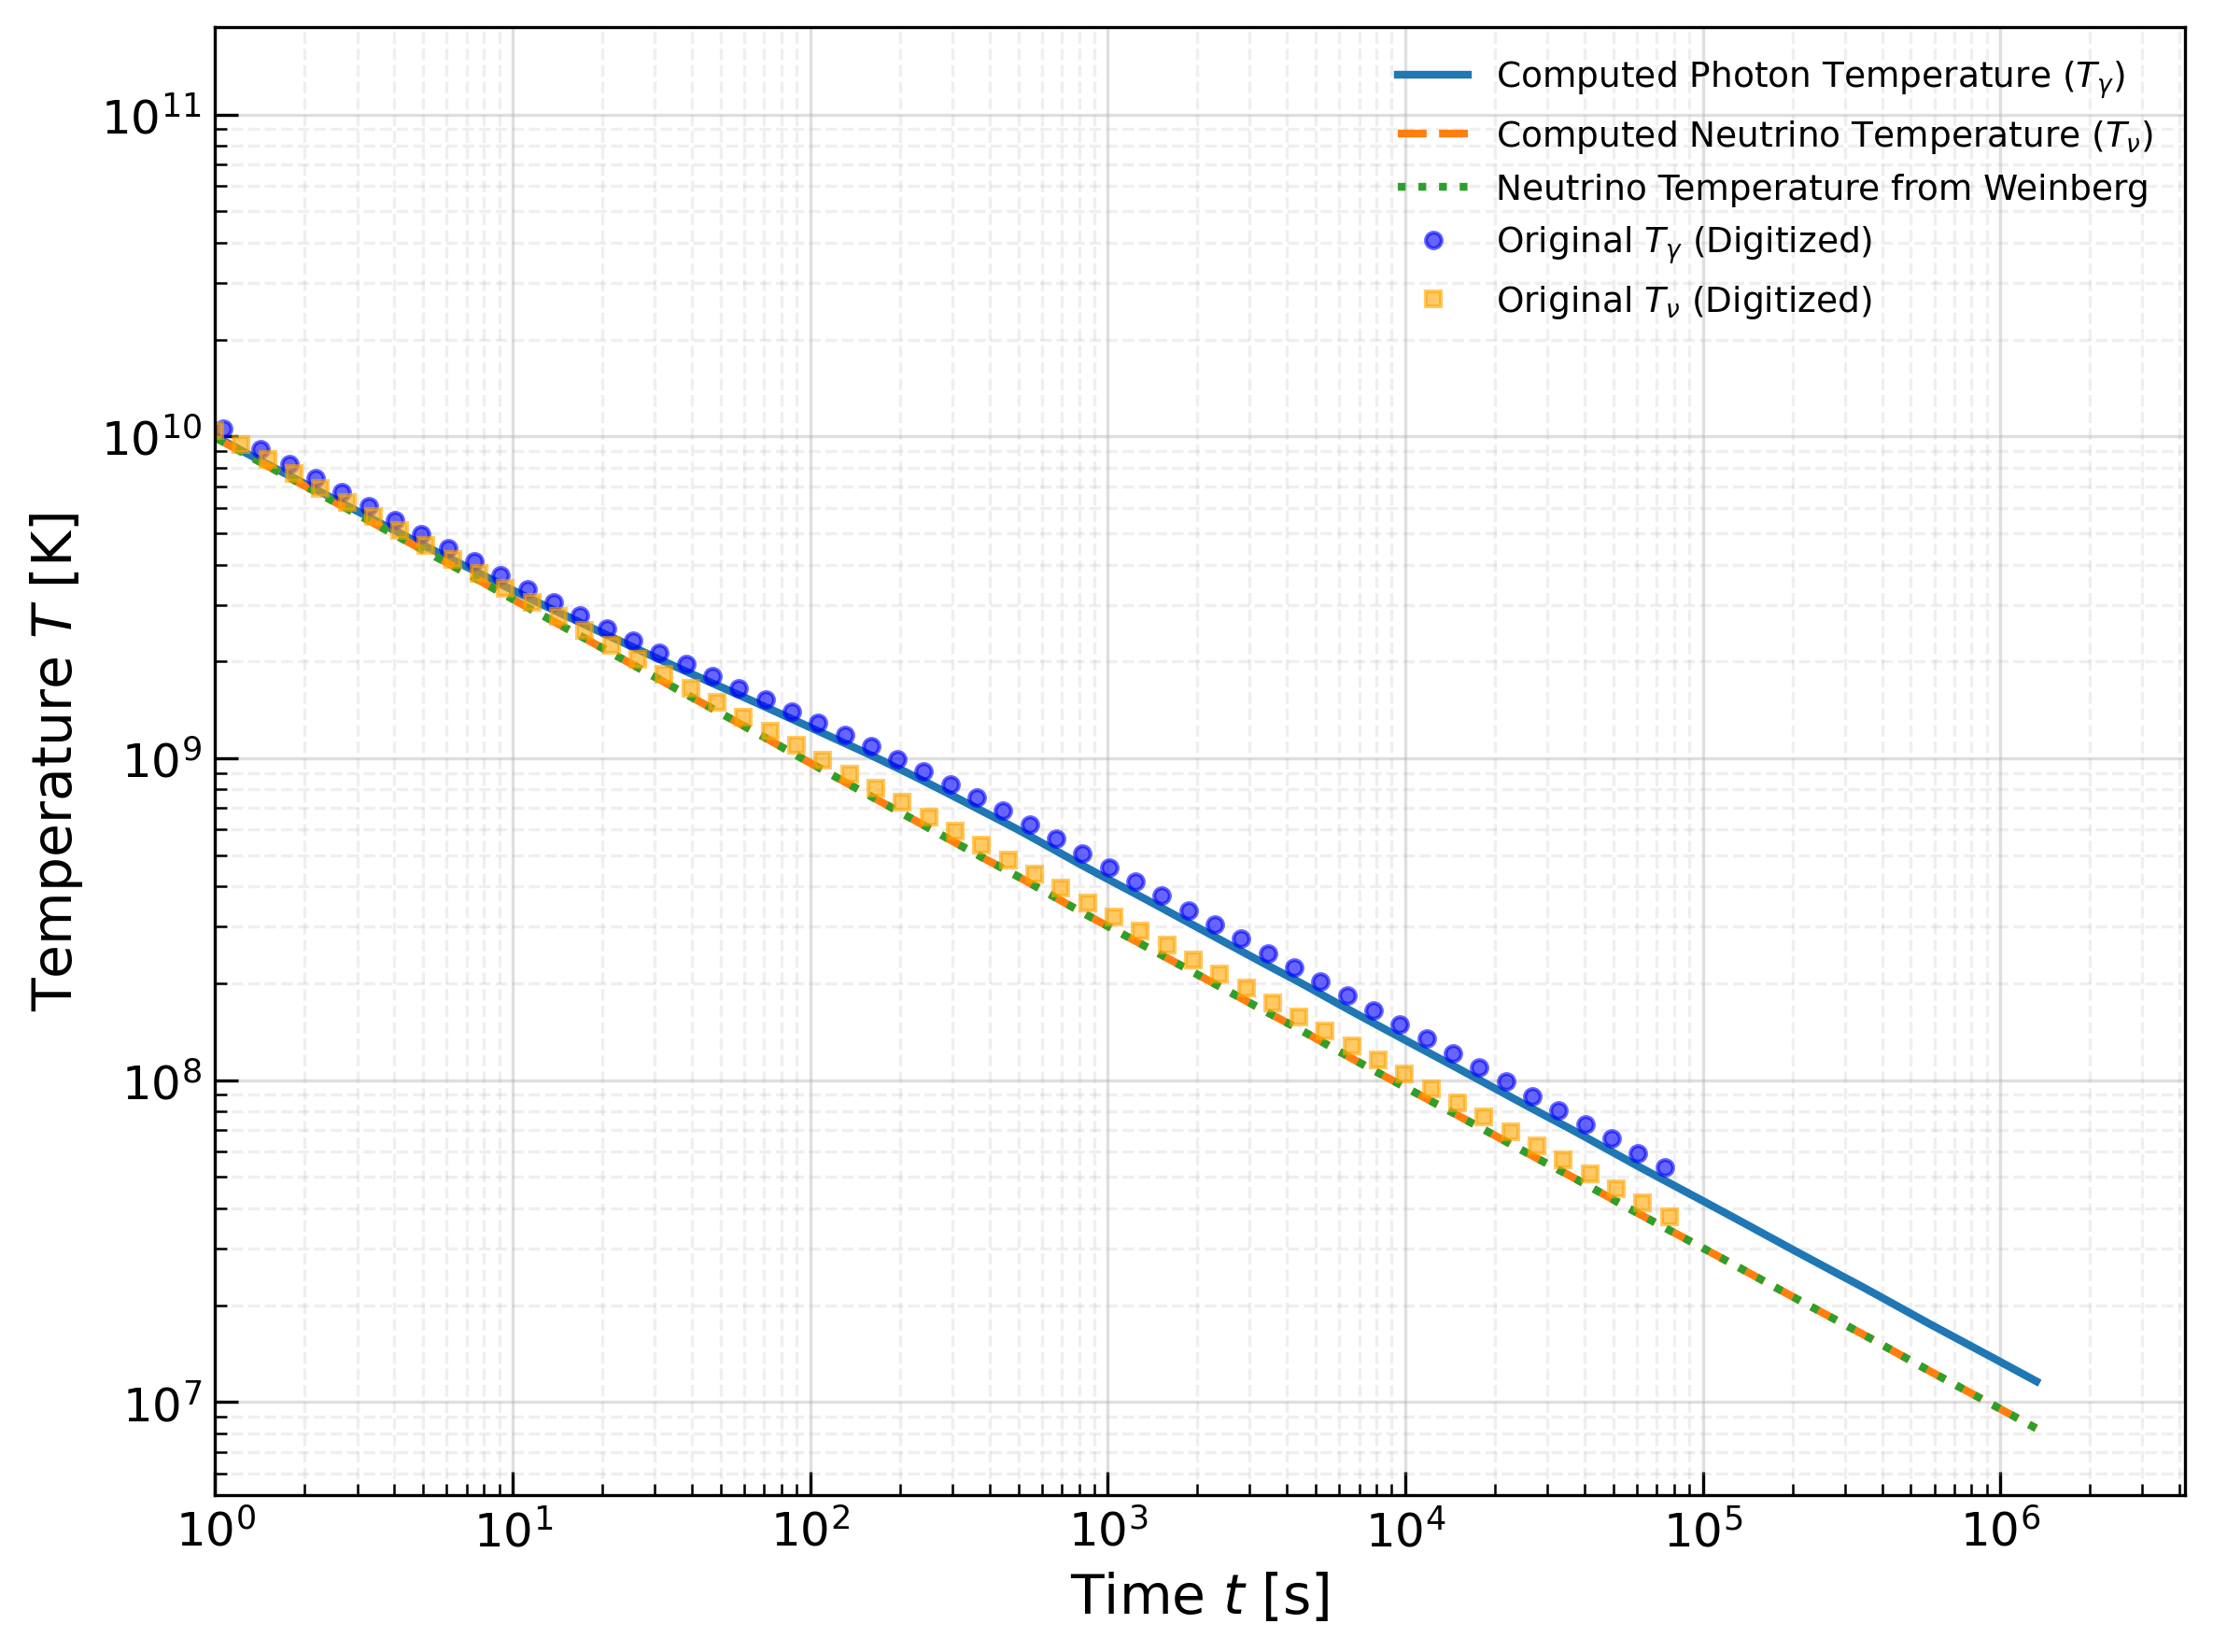

In [59]:
# Load digitized data from CSV files
T_nu_digitized = np.loadtxt('digitized-plots/BBN-simple-plots/Tnu-and-Tgamma/T-nu.csv', delimiter=',')
T_gamma_digitized = np.loadtxt('digitized-plots/BBN-simple-plots/Tnu-and-Tgamma/T-gamma.csv', delimiter=',')

# Plotting the evolution of photon and neutrino temperatures

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6), dpi=300)

# Plot the computed temperatures
plt.loglog(t, MeVtoK(T), label=r'Computed Photon Temperature ($T_\gamma$)', linewidth=2)
plt.loglog(t, MeVtoK(Tnu), label=r'Computed Neutrino Temperature ($T_\nu$)', linewidth=2, linestyle='--')
plt.loglog(t, MeVtoK(Tnu_weinberg), label=r'Neutrino Temperature from Weinberg', linewidth=2, linestyle=':')

# Plot the digitized original data (multiplying by 1e9 since digitized data is in T9)
plt.loglog(T_gamma_digitized[:, 0], 1e9 * T_gamma_digitized[:, 1], 'o', label=r'Original $T_\gamma$ (Digitized)', markersize=4, alpha=0.6, color='blue')
plt.loglog(T_nu_digitized[:, 0], 1e9 * T_nu_digitized[:, 1], 's', label=r'Original $T_\nu$ (Digitized)', markersize=4, alpha=0.6, color='orange')

# Axis limits and labels
plt.xlim(left=1) # Keeping your lower limit constraint
plt.xlabel(r'Time $t$ [s]', fontsize=14)
plt.ylabel(r'Temperature $T$ [K]', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


---

### Weak interaction rates and neutrino decoupling 

In [60]:
# Function which calculates the weak interaction rates 

def WeakRate(T, Tnu):

    # Setting up the necessary constants and parameters 
    q = Q/me
    z = me/T
    z_nu = me/Tnu

    def K_integrand(x):   # The T = 0 limit of the lambda function, which is used to find the normalization factor K

        return  x * (x - q)**2 * np.sqrt(x**2 - 1)

    K_integral = sp.integrate.quad(K_integrand, 1, q)[0]

    K = (1/tau_n) * 1/K_integral

    
    # Writing out the reaction rates 
    def integrand_1(x): 

        x = x + 1   # performing a change of variables so that the limits of integration becomes 0 to inf

        numerator = x * (x+q)**2 * np.sqrt(x**2 - 1)
        denominator = (1 + exp(x*z)) * ( 1 + exp(-(x+q) * z_nu) )

        return numerator/denominator

    def integrand_2(x): 

        x = x + 1   # performing a change of variables so that the limits of integration becomes 0 to inf

        numerator = x * (x-q)**2 * np.sqrt(x**2 - 1)
        denominator = (1 + exp(-x*z)) * ( 1 + exp((x-q) * z_nu) )
        
        return numerator/denominator

    
    # Performing the integral using the GL quadrature 
    integral_1 = gl_integrator(integrand_1)
    integral_2 = gl_integrator(integrand_2)


    # Final reaction rate for n -> p 
    lambda_np = K * (integral_1 + integral_2)



    # For the reverse process, we just need to flip the sign of q and proceed the same way

    q = - q 

    # Performing the integrals 
    rev_integral_1 = gl_integrator(integrand_1)
    rev_integral_2 = gl_integrator(integrand_2)

    # Final reaction rate for p -> n 
    lambda_pn = K * (rev_integral_1 + rev_integral_2)


    return lambda_np, lambda_pn



# Defining a function which calculates the abundances of n and p 
# at Nuclear Stability Equilibrium (NSE) conditions 

def NSE_np_abundance(T):    # Input: Temperature (MeV)

    '''
    Returns the mass fractions of neutrons and protons 
    in NSE equilibrium conditions at a temperature T

    Input: Temperature (MeV)
    Output: [Neutron mass fraction, Proton mass fraction]
    '''

    X_n = 1 / (1 + exp(Q/T))
    X_p = 1 / (1 + exp(-Q/T))

    return X_n, X_p


In [61]:
# Calculating and plotting the weak interaction rates 

lambda_n2p = []
lambda_p2n = []

for i in range(len(T)):
    rate = WeakRate(T[i], Tnu[i])
    lambda_n2p.append(rate[0])
    lambda_p2n.append(rate[1]) 

    # also adding them to the dictionaries 

    # func_of_T[T[i]].append(rate[0])
    # func_of_T[T[i]].append(rate[1])

    # func_of_t[t[i]].append(rate[0])
    # func_of_t[t[i]].append(rate[1])

lambda_n2p = np.array(lambda_n2p)
lambda_p2n = np.array(lambda_p2n)


# Creating functions for the rates as a function of time

n2p_rate = sp.interpolate.interp1d(t, lambda_n2p, kind= "cubic")
p2n_rate = sp.interpolate.interp1d(t, lambda_p2n, kind= "cubic")


/tmp/ipykernel_7121/4222713196.py:8: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/tmp/ipykernel_7121/133435051.py:25: RuntimeWarning: overflow encountered in multiply
  denominator = (1 + exp(x*z)) * ( 1 + exp(-(x+q) * z_nu) )


The dictionaries, `func_of_t` and `func_of_T` repsectively now read: 

$$ \text{func\_of\_t} = \{ t: \; T, \; T_\nu, \; \lambda_{n \rightarrow p}, \; \lambda_{p \rightarrow n} \} $$

$$ \text{func\_of\_t} = \{ T: \; t, \; T_\nu, \; \lambda_{n \rightarrow p}, \; \lambda_{p \rightarrow n} \} $$

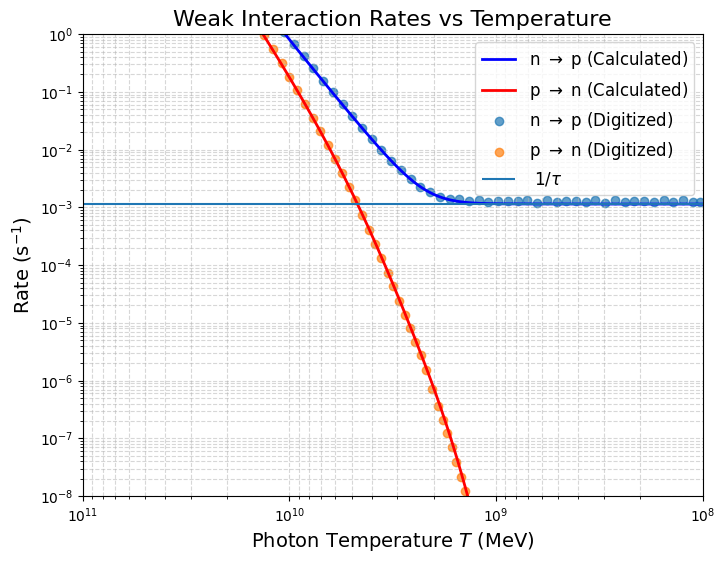

In [62]:

# Read the digitized data for comparison
n2p_data = pd.read_csv('digitized-plots/BBN-simple-plots/Weak-rates/n2p.csv', header=None, names=['T', 'Rate'])
p2n_data = pd.read_csv('digitized-plots/BBN-simple-plots/Weak-rates/p2n.csv', header=None, names=['T', 'Rate'])

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot our numerical results
ax1.plot(MeVtoK(T), lambda_n2p, 'b-', label='n $\\rightarrow$ p (Calculated)', linewidth=2)
ax1.plot(MeVtoK(T), lambda_p2n, 'r-', label='p $\\rightarrow$ n (Calculated)', linewidth=2)

# Plot the digitized data for comparison
ax1.scatter(n2p_data['T'] * 1e9, n2p_data['Rate'], label='n $\\rightarrow$ p (Digitized)', alpha=0.7)
ax1.scatter(p2n_data['T'] * 1e9, p2n_data['Rate'], label='p $\\rightarrow$ n (Digitized)', alpha=0.7)

# Adding a dashed line representing the asymptotic limit 

ax1.hlines(1/tau_n, xmin=1e11, xmax=1e8, label=' $1/\\tau$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Photon Temperature $T$ (MeV)', fontsize=14)
ax1.set_ylabel('Rate (s$^{-1}$)', fontsize=14)
ax1.set_title('Weak Interaction Rates vs Temperature', fontsize=16)

# Reverse the x-axis so that high temp (early times) are on the left
ax1.set_xlim(1e11, 1e8)
ax1.set_ylim(1e-8, 1e0)

ax1.legend(fontsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.5)


plt.show()


$$ \frac{d X_n}{dt} = \lambda_{p \rightarrow n} X_n - \lambda_{n \rightarrow p} X_p $$
$$ \frac{d X_p}{dt} = \lambda_{n \rightarrow p} X_p - \lambda_{p \rightarrow n} X_n $$

Doing, a chain rule substitution, we get:

$$ \frac{d X}{dt} = \frac{d X}{dT}  \frac{dT}{dt} $$

Substituting this back, we get: 

$$ \frac{d X_n}{dT} = \left( \lambda_{p \rightarrow n} X_n - \lambda_{n \rightarrow p} X_p \right) \cdot \frac{dt}{dT} $$
$$ \frac{d X_p}{dT} = \left( \lambda_{n \rightarrow p} X_p - \lambda_{p \rightarrow n} X_n \right) \cdot \frac{dt}{dT} $$

So we get a system of coupled differential equations, which we solve below

In [63]:
# Calculating the evolution of the abundances of protons and neutrons over time(temperature)

def n_p_abundance(T, state): 

    t, Tnu, X_n, X_p = state 

    # Some constants 

    lambda_n2p = WeakRate(T, Tnu)[0]
    lambda_p2n = WeakRate(T, Tnu)[1]

    # Differential equations for the abundances of neutrons and protons

    dt_dT = T_dependence(T, [t, Tnu])[0]

    dTnu_dT = T_dependence(T, [t, Tnu])[1]

    dXn_dT = ( lambda_p2n * X_p - lambda_n2p * X_n ) * dt_dT 

    dXp_dT = ( lambda_n2p * X_n - lambda_p2n * X_p ) * dt_dT

    return [dt_dT, dTnu_dT, dXn_dT, dXp_dT]


# Solving the system of D.E's

# Initial conditions for Xn and Xp 
# (They were still in equilibrium then, so we use NSE condition)

Xn_initial = NSE_np_abundance(Ti)[0]
Xp_initial = NSE_np_abundance(Ti)[1]

# Calculating the abundances at all temperatures

abundance = sp.integrate.solve_ivp(fun= n_p_abundance, t_span= T[[0, -1]], y0= [0, Ti, Xn_initial, Xp_initial], t_eval= T, method= 'Radau')
t = abundance.y[0]
Tnu = abundance.y[1]
X_n = abundance.y[2]
X_p = abundance.y[3]

/tmp/ipykernel_7121/4222713196.py:8: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/tmp/ipykernel_7121/133435051.py:25: RuntimeWarning: overflow encountered in multiply
  denominator = (1 + exp(x*z)) * ( 1 + exp(-(x+q) * z_nu) )


/tmp/ipykernel_7121/4222713196.py:8: RuntimeWarning: overflow encountered in exp
  return np.exp(x)


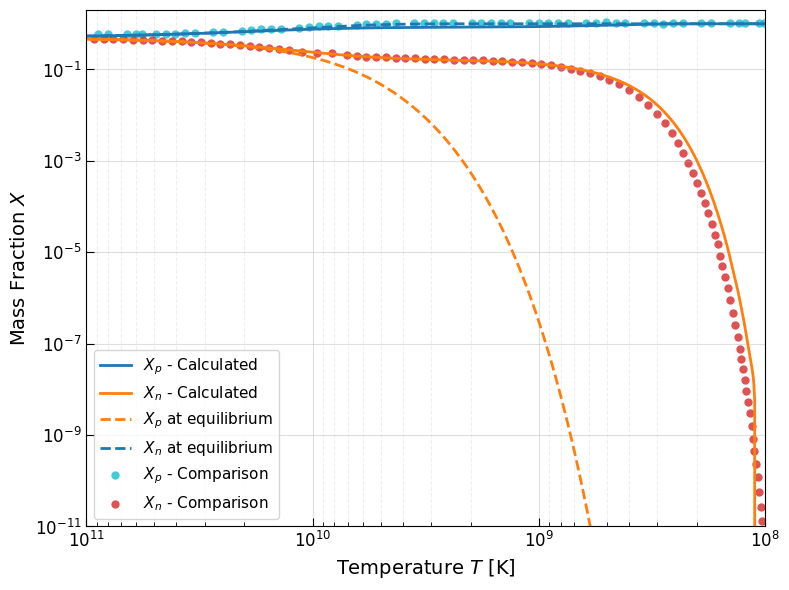

In [64]:
# Calculating the evolution of the abundances of protons and neutrons over time(temperature)

# Load the digitized comparison data from the provided CSV files
Xn_data = np.loadtxt('digitized-plots/BBN-simple-plots/n-p-fraction-evolution/Xn.csv', delimiter=',')
Xp_data = np.loadtxt('digitized-plots/BBN-simple-plots/n-p-fraction-evolution/Xp.csv', delimiter=',')

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6))

# Plot your calculated abundance evolution
plt.plot(MeVtoK(T), X_p, label=r'$X_p$ - Calculated', linewidth=2, color='tab:blue')
plt.plot(MeVtoK(T), X_n, label=r'$X_n$ - Calculated', linewidth=2, color='tab:orange')


# Plotting the abundance evolution of equilibrium still existed 

plt.plot(MeVtoK(T), NSE_np_abundance(T)[0], '--', label=r'$X_p$ at equilibrium', linewidth=2, color='tab:orange')
plt.plot(MeVtoK(T), NSE_np_abundance(T)[1], '--', label=r'$X_n$ at equilibrium',  linewidth=2, color='tab:blue')


# Overlay the digitized comparison data

plt.scatter(Xp_data[:, 0], Xp_data[:, 1], label=r'$X_p$ - Comparison'
            , linewidth=0, color='tab:cyan', alpha=0.8)

plt.scatter(Xn_data[:, 0], Xn_data[:, 1], label=r'$X_n$ - Comparison'
            , linewidth=0, color='tab:red', alpha=0.8)            


# Axis limits and labels
plt.xlim(1e11, 1e8)  # Reversing x-axis to show temperature dropping from left to right
plt.ylim(1e-11, 2) # You can uncomment this if you want to bound the y-axis explicitly
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Temperature $T$ [K]', fontsize=14)
plt.ylabel(r'Mass Fraction $X$', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=11, frameon=True, loc='best')

plt.tight_layout()
plt.show()


### BBN START!

After the neutron freeze-out we can start worrying about the abundances of the other elements. The reactions that we would be considering are given below: 


$$
\begin{aligned}
n &\rightleftharpoons p \\
p + n &\rightleftharpoons \mathrm{D} + \gamma \\
\mathrm{D} + \mathrm{p} &\rightleftharpoons {}^{3}\mathrm{He} + \gamma \\
\mathrm{D} + \mathrm{D} &\rightleftharpoons \mathrm{n} + {}^{3}\mathrm{He} \\
\mathrm{D} + \mathrm{D} &\rightleftharpoons \mathrm{p} + \mathrm{T} \\
{}^{3}\mathrm{He} + \mathrm{n} &\rightleftharpoons \mathrm{p} + \mathrm{T} \\
\mathrm{T} + \mathrm{D} &\rightleftharpoons \mathrm{n} + {}^{4}\mathrm{He} \\
{}^{3}\mathrm{He} + \mathrm{D} &\rightleftharpoons \mathrm{p} + {}^{4}\mathrm{He} \\
{}^{3}\mathrm{He} + {}^{4}\mathrm{He} &\rightleftharpoons {}^{7}\mathrm{Be} + \gamma \\
\mathrm{T} + {}^{4}\mathrm{He} &\rightleftharpoons {}^{7}\mathrm{Li} + \gamma \\
{}^{7}\mathrm{Be} + \mathrm{n} &\rightleftharpoons \mathrm{p} + {}^{7}\mathrm{Li} \\
{}^{7}\mathrm{Li} + \mathrm{p} &\rightleftharpoons {}^{4}\mathrm{He} + {}^{4}\mathrm{He}
\end{aligned}
$$

The mass fraction of the different elements involved ($\mathrm{D}, \mathrm{T}, {}^3\mathrm{He}, {}^4\mathrm{He}, {}^7\mathrm{Li}, {}^7\mathrm{Be}$) at equilibrium is calculated using the following equation: 


$$X_A = g_A \left(\zeta (3)^{A-1} \pi^{(1-A)/2} 2^{(3A-5)/2}\right) A^{5/2} \left(\frac{T}{m_n}\right)^{3(A-1)/2} \eta^{A-1} X_p^Z X_n^{A-Z} \exp(B_A/T)$$

In [65]:
def NSE_abundance(T, Z, A, B_A, s_A):

    '''
    Calculates the mass fraction of provided element 
    during NSE conditions at a specified temperature.

    Input: Temperature (MeV), Atomic Number (Z), Mass number (A), Binding energy (B_A), spin of element (s_A)
    Output: Mass fraction of the element at that temperature
    '''

    g_A = 2*s_A + 1
    
    X_p = NSE_np_abundance(T)[1]  
    X_n = NSE_np_abundance(T)[0]

    return g_A * ( zeta(3)**(A-1) * pi**((1-A)/2) * 2**((3*A-5)/2) ) * A**(5/2) * (T/mn)**((A-1)*3/2) * eta0**(A-1) * X_p**(Z) * X_n**(A-Z) * exp(B_A/T)

# Storing all the initial mass fractions in an easy to access dictionary

X_initial = {
    "n":   NSE_np_abundance(Ti)[0],
    "p":   NSE_np_abundance(Ti)[1],
    "D":   NSE_abundance(Ti, Deut["Z"], Deut["A"], Deut["B"], Deut["s"]),
    "T":   NSE_abundance(Ti, Trit["Z"], Trit["A"], Trit["B"], Trit["s"]), 
    "He3": NSE_abundance(Ti, He3["Z"], He3["A"], He3["B"], He3["s"]), 
    "He4": NSE_abundance(Ti, He4["Z"], He4["A"], He4["B"], He4["s"]), 
    "Li7": NSE_abundance(Ti, Li7["Z"], Li7["A"], Li7["B"], Li7["s"]), 
    "Be7": NSE_abundance(Ti, Be7["Z"], Be7["A"], Be7["B"], Be7["s"])
}

# Using Y = X/A to get the initial abundances in terms of number density instead of mass density
# which would be helpful later on.

Y_initial = {
    "n":   X_initial["n"], 
    "p":   X_initial["p"],
    "D":   X_initial["D"] / Deut["A"],
    "T":   X_initial["T"] / Trit["A"],
    "He3": X_initial["He3"] / He3["A"],
    "He4": X_initial["He4"] / He4["A"],
    "Li7": X_initial["Li7"] / Li7["A"],
    "Be7": X_initial["Be7"] / Be7["A"]
}

Next, we need to calculate the reaction cross sections that are involved 

In [66]:
# Defining the reaction parameters from REACLIB database 
# storing the reaction parameters in a dictionary for each reaction. 


# p + n -> D + γ 
Rxn_pn_to_D = {
    "q": 2.22457e+00, 
    "a_forward": [
        [8.846880e+00, 0.000000e+00, 0.000000e+00, -1.020820e-02, -8.939590e-02, 6.967040e-03, 1.000000e+00], 
        [1.236870e+01, 0.000000e+00, 0.000000e+00, -2.706180e+00, 1.171800e-01, -3.127880e-03, 4.691270e-01],
        [1.075480e+01, 0.000000e+00, 0.000000e+00, -2.304720e+00, -8.878620e-01, 1.376630e-01, 0.000000e+00]
        ], 
    "a_reverse": [
        [3.110750e+01, -2.581500e+01, 0.000000e+00, -1.020820e-02, -8.939590e-02, 6.967040e-03, 2.500000e+00],
        [3.462930e+01, -2.581500e+01, 0.000000e+00, -2.706180e+00, 1.171800e-01, -3.127880e-03, 1.969130e+00],
        [3.301540e+01, -2.581500e+01, 0.000000e+00, -2.304720e+00, -8.878620e-01, 1.376630e-01, 1.500000e+00]
    ]
} 

# D + p -> He3 + γ
Rxn_Dp_to_He3 = {
    "q": 5.49348,
    "a_forward": [
        [6.732230e+00, -4.379150e-04, -3.583620e+00, 2.882830e+00, -1.186750e-01, -4.208940e-16, -6.131680e-01]
    ], 
    "a_reverse": [
        [3.023518e+01, -6.375227e+01, -3.583620e+00, 2.882830e+00, -1.186750e-01, -4.208940e-16, 8.868320e-01]
    ]
}

# D + D -> He3 + n 
Rxn_DD_to_He3n = {
    "q": 3.2688999176, 
    "a_forward": [
        [1.908764e+01, -1.900204e-04, -4.229198e+00, 1.693199e+00, -8.555288e-02, -1.357093e-25, -7.345125e-01]
    ],
    "a_reverse": [
        [1.963695e+01, -3.793577e+01, -4.229198e+00, 1.693199e+00, -8.555288e-02, -1.357093e-25, -7.345125e-01]
    ]
}

# D + D -> p + T
Rxn_DD_to_p_T = {
    "q": 4.03266e+00,
    "a_forward": [
        [1.880517e+01, 4.362085e-05, -4.322961e+00, 1.915721e+00, -8.156203e-02, -3.288043e-22, -8.795180e-01]
    ],
    "a_reverse": [
        [1.935448e+01, -4.679897e+01, -4.322961e+00, 1.915721e+00, -8.156203e-02, -3.288043e-22, -8.795180e-01]
    ]
}

# He3 + n -> T + p
Rxn_He3n_to_Tp = {
    "q": 0.763800024986, 
    "a_forward": [
        [2.037870e+01, 0.000000e+00, 0.000000e+00, -3.327880e-01, -7.004850e-01, 9.765210e-02, 0.000000e+00],
        [1.927620e+01, 0.000000e+00, 0.000000e+00, 4.385570e-02, -2.015270e-01, 1.534330e-02, 1.000000e+00]
    ],
    "a_reverse": [
        [2.037870e+01, -8.863520e+00, 0.000000e+00, -3.327880e-01, -7.004850e-01, 9.765210e-02, 0.000000e+00],
        [1.927620e+01, -8.863520e+00, 0.000000e+00, 4.385570e-02, -2.015270e-01, 1.534330e-02, 1.000000e+00]
    ]
}

# T + D -> n + He4
Rxn_TD_to_nHe4 = {
    "q": 1.75890e+01,
    "a_forward": [
        [3.934570e+01, 0.000000e+00, -4.524400e+00, -1.640280e+01, 1.731030e+00, -1.229660e-01, 2.313040e+00],
        [2.517940e+01, 0.000000e+00, -4.524400e+00, 3.503370e-01, 5.874700e-01, -8.849090e+00, -6.666670e-01]
    ],
    "a_reverse": [
        [2.688620e+01, -2.041120e+02, -4.524400e+00, 3.503370e-01, 5.874700e-01, -8.849090e+00, -6.666670e-01],
        [4.105250e+01, -2.041120e+02, -4.524400e+00, -1.640280e+01, 1.731030e+00, -1.229660e-01, 2.313040e+00]
    ]
}

# He3 + D -> p + He4
Rxn_He3D_to_pHe4 = {
    "q": 18.3530006409, 
    "a_forward": [
        [2.468390e+01, 0.000000e+00, -7.182000e+00, 4.732880e-01, 1.468470e+00, -2.796030e+01, -6.666670e-01],
        [4.129690e+01, 0.000000e+00, -7.182000e+00, -1.713490e+01, 1.369080e+00, -8.144230e-02, 3.353950e+00]
    ],
    "a_reverse": [
        [2.639070e+01, -2.129770e+02, -7.182000e+00, 4.732880e-01, 1.468470e+00, -2.796030e+01, -6.666670e-01],
        [4.300370e+01,-2.129770e+02, -7.182000e+00, -1.713490e+01, 1.369080e+00, -8.144230e-02, 3.353950e+00]
    ]
}

# He3 + He4 -> γ + Be7
Rxn_He3He4_to_Be7 = {
    "q": 1.58609998226,
    "a_forward": [
        [1.560990e+01, 0.000000e+00, -1.282710e+01, -3.082250e-02, -6.546850e-01, 8.963310e-02, -6.666670e-01],
        [1.770750e+01, 0.000000e+00, -1.282710e+01, -3.812600e+00, 9.422850e-02, -3.010180e-03, 1.333330e+00]
    ],
    "a_reverse": [
        [3.873790e+01, -1.840590e+01, -1.282710e+01, -3.082250e-02, -6.546850e-01, 8.963310e-02, 8.333330e-01],
        [4.083550e+01, -1.840590e+01, -1.282710e+01, -3.812600e+00, 9.422850e-02, -3.010180e-03, 2.833330e+00]
    ]
}

# T + He4 -> γ + Li7 
Rxn_THe4_to_Li7 = {
    "q": 2.46700000763, 
    "a_forward": [
        [1.361620e+01, 0.000000e+00, -8.080500e+00, -2.175140e-01, -1.148590e-01, 4.700430e-02, -6.666670e-01]
    ],
    "a_reverse": [
        [3.674420e+01, -2.862830e+01, -8.080500e+00, -2.175140e-01, -1.148590e-01, 4.700430e-02, 8.333330e-01]
    ]
}

# Be7 + n -> p + Li7
Rxn_Be7n_to_pLi7 = {
    "q": 1.64400005341, 
    "a_forward": [
        [2.178985e+01, 7.280980e-04, -3.025400e-01, -3.602000e-01, 1.747200e-01, -2.230000e-02, -4.581000e-01]
    ],
    "a_reverse": [
        [2.178985e+01, -1.907789e+01, -3.025400e-01, -3.602000e-01, 1.747200e-01, -2.230000e-02, -4.581000e-01]
    ]
}
        
# Li7 + p -> He4 + He4
Rxn_Li7p_to_He4He4 = {
    "q": 17.3470001221, 
    "a_forward": [
        [2.044380e+01, 0.000000e+00, -8.472700e+00, 2.979340e-01, 5.823350e-02, -4.133830e-03, -6.666670e-01], 
        [2.189990e+01, -2.615270e+01, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, -1.500000e+00], 
        [1.195760e+01, 0.000000e+00, -8.472700e+00, 4.179430e-01, 5.345650e+00, -4.868400e+00, -6.666670e-01], 
        [1.425380e+01, -4.478000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, -1.500000e+00]
    ],
    "a_reverse": [
        [1.349020e+01, -2.013120e+02, -8.472700e+00, 4.179430e-01, 5.345650e+00, -4.868400e+00, -6.666670e-01],
        [1.578640e+01, -2.057900e+02, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, -1.500000e+00], 
        [2.197640e+01, -2.013120e+02, -8.472700e+00, 2.979340e-01, 5.823350e-02, -4.133830e-03, -6.666670e-01],
        [2.343250e+01, -2.274650e+02, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, -1.500000e+00]
    ]
}


# Comibining all the reactions into a single dictionary for easy access

Rxn_dict = {
    "p+n->D+gamma": Rxn_pn_to_D,
    1: Rxn_pn_to_D,  # Allowing access by index as well
    "D+p->He3+gamma": Rxn_Dp_to_He3,
    2: Rxn_Dp_to_He3,  # Allowing access by index as well
    "D+D->He3+n": Rxn_DD_to_He3n,
    3: Rxn_DD_to_He3n,  # Allowing access by index as well
    "D+D->p+T": Rxn_DD_to_p_T,
    4: Rxn_DD_to_p_T,  # Allowing access by index as well
    "He3+n->T+p": Rxn_He3n_to_Tp,
    5: Rxn_He3n_to_Tp,  # Allowing access by index as well
    "T+D->n+He4": Rxn_TD_to_nHe4,
    6: Rxn_TD_to_nHe4,  # Allowing access by index as well
    "He3+D->p+He4": Rxn_He3D_to_pHe4,
    7: Rxn_He3D_to_pHe4,  # Allowing access by index as well
    "He3+He4->gamma+Be7": Rxn_He3He4_to_Be7,
    8: Rxn_He3He4_to_Be7,  # Allowing access by index as well
    "T+He4->gamma+Li7": Rxn_THe4_to_Li7,
    9: Rxn_THe4_to_Li7,  # Allowing access by index as well
    "Be7+n->p+Li7": Rxn_Be7n_to_pLi7,
    10: Rxn_Be7n_to_pLi7,  # Allowing access by index as well
    "Li7+p->He4+He4": Rxn_Li7p_to_He4He4,
    11: Rxn_Li7p_to_He4He4  # Allowing access by index as well
}


def crosssection(T, reaction):  # input: Temperature (MeV), reaction name (string) or index (int)

    '''
    Returns the thermally averaged cross-section (N_A * <σv>) of the specified reaction at 
    the temperature T. 

    INPUT: Temperature (MeV), "a" values as an array for the reaction (from the REACLIB database)
    OUTPUT: N_A * <σv> in units of cm^3 mol^-1 s^-1
    '''

    T9 = MeVtoK9(T)   # converting the temp from MeV to T9 

    T9_clip = np.clip(T9, 1e-3, 15) # T9 will stay between 1e-3 and 15, as the REACLIB database is only valid in this range  

    a = Rxn_dict[reaction]["a_forward"]  # Getting the "a" values for the reaction
    sigma = 0

    for a_i in a: 

        a0, a1, a2, a3, a4, a5, a6 = a_i

        sigma += exp(
        a0 + a1/T9_clip + a2/(T9_clip**(1/3)) + a3*(T9_clip**(1/3)) + a4*T9_clip + a5*(T9_clip**(5/3)) + a6*np.log(T9_clip)
        )

    return sigma


# Defining a separate reverse cross section thingy 

def reverse_crosssection(T, reaction):  # input: Temperature (MeV), reaction name (string) or index (int)

    T9 = MeVtoK9(T)   

    rhob = h * (T9)**3

    conversion = 0.98677e10

    an, ap, ad, at, a3, a4, ali7, abe7 = np.array([mn, mp, md, mt, m3, m4, mli7, mbe7])/amu

    mass_excess = MeVtoK9(np.array([
            2.22457,5.493, 3.2689 ,4.03266,0.7638, 17.589 , 18.353, 1.5861,2.467, 1.644, 17.347 
            ]))

    if reaction == "p+n->D+gamma": 
        rev_cross = conversion*((2*2)/(3) * ((an*ap)/(ad))**(3/2)* rhob**(-1) * T9**(3/2) * np.exp(-mass_excess[0]/(T9)))

    elif reaction == "D+p->He3+gamma":
        rev_cross = conversion*((3*2)/(2) * ((ad*ap)/(a3))**(3/2)* rhob**(-1) * T9**(3/2)* np.exp(-mass_excess[1]/(T9)))

    elif reaction == "D+D->He3+n":
        rev_cross = (3*3)/(2*2) * ((ad*ad)/(an*a3))**(3/2)* np.exp(-mass_excess[2]/(T9))

    elif reaction == "D+D->p+T":
        rev_cross = (3*3)/(2*2) * ((ad*ad)/(ap*at))**(3/2)* np.exp(-mass_excess[3]/(T9))

    elif reaction == "He3+n->T+p":
        rev_cross = (2*2)/(2*2) * ((a3*an)/(ap*at))**(3/2)* np.exp(-mass_excess[4] /(T9))

    elif reaction == "T+D->n+He4":
        rev_cross = (2*3)/(2*1) * ((at*ad)/(an*a4))**(3/2)* np.exp(-mass_excess[5]/(T9))

    elif reaction == "He3+D->p+He4":
        rev_cross = (2*3)/(2*1) * ((a3*ad)/(ap*a4))**(3/2)* np.exp(-mass_excess[6]/(T9))

    elif reaction == "He3+He4->gamma+Be7":
        rev_cross = conversion*((2*1)/(4) * ((a3*a4)/(abe7))**(3/2)* rhob**(-1) * T9**(3/2)* np.exp(-mass_excess[7]/(T9)))

    elif reaction == "T+He4->gamma+Li7":
        rev_cross = conversion*((2*1)/(4) * ((at*a4)/(ali7))**(3/2)* rhob**(-1) * T9**(3/2)* np.exp(-mass_excess[8]/(T9)))

    elif reaction == "Be7+n->p+Li7":
        rev_cross = (2*4)/(2*4) * ((an*abe7)/(ap*ali7))**(3/2)* np.exp(-mass_excess[9]/(T9))

    elif reaction == "Li7+p->He4+He4":
        rev_cross = (4*1)/(1*1) * ((ali7*ap)/(a4*a4))**(3/2)* np.exp(-mass_excess[10]/(T9))

    else: 
        raise ValueError("Reaction not recognized. Please check the reaction name.")

    return rev_cross * crosssection(T, reaction)



Text(0.5, 1.0, 'Comparison of forward cross sections for T + D -> n + He4')

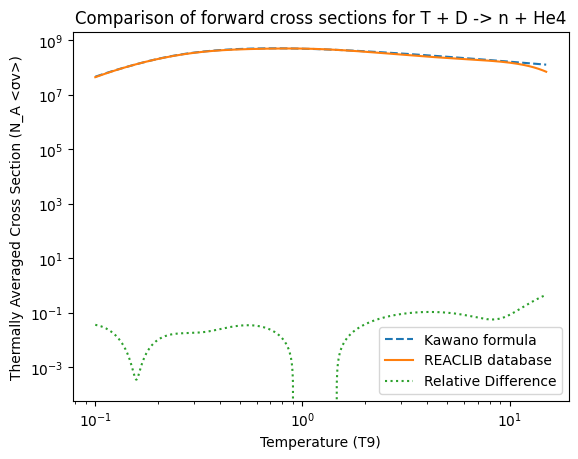

In [67]:
# Comparison plot between the cross sections from the REACLIB database and the Kawano formula for the t + D -> n + He4 reaction

T_test = np.geomspace(0.1, 15, 1000)  # in K9

kawano_form = 1.063e11 * T_test**(-2/3) * np.exp(-4.559/(T_test**(1/3)) - (T_test/0.0754)**2) * (1 + 0.092*T_test**(1/3) - 0.375*T_test**(2/3) - 0.242*T_test + 33.82*T_test**(4/3) + 55.42*T_test**(5/3)) + 8.047e8*T_test**(-2/3) * np.exp(-0.4857/T_test)

reaclib_form = crosssection(K9toMeV(T_test), "T+D->n+He4")

plt.plot(T_test, kawano_form, '--', label='Kawano formula')
plt.plot(T_test, reaclib_form, label='REACLIB database')
plt.plot(T_test, (kawano_form - reaclib_form)/kawano_form, ':', label='Relative Difference')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Temperature (T9)')
plt.ylabel('Thermally Averaged Cross Section (N_A <σv>)')
plt.title('Comparison of forward cross sections for T + D -> n + He4')

In [68]:
rhob = h * T9**3 

# Importing the comparison data for the density
df = pd.read_csv("digitized-plots/BBN-simple-plots/ForwardRate_cross_sections.csv")

df_rev = pd.read_csv("digitized-plots/BBN-simple-plots/ReverseRate_cross_sections.csv")


Text(0.5, 1.0, 'Forward Cross Sections for BBN Reactions')

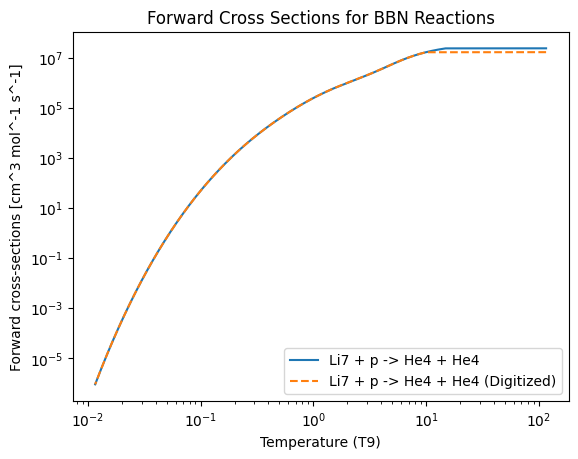

In [69]:
# Plotting the time evolution of the thermally averaged cross sections for all the reactions 

# plt.figure(figsize=(8, 6), dpi=1000)

# plt.loglog(T9, crosssection(T, "p+n->D+gamma"), label='p + n -> D + γ')
# plt.loglog(T9, df['p+n->D+γ']/rhob, label='p + n -> D + γ (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "D+p->He3+gamma"), label='D + p -> He3 + γ')
# plt.loglog(T9, df['D+p->He3+γ']/rhob, label='D + p -> He3 + γ (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "D+D->He3+n"), label='D + D -> He3 + n')
# plt.loglog(T9, df['D+D->n+He3']/rhob, label='D + D -> He3 + n (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "D+D->p+T"), label='D + D -> p + T')
# plt.loglog(T9, df['D+D->p+T']/rhob, label='D + D -> p + T (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "He3+n->T+p"), label='He3 + n -> T + p')
# plt.loglog(T9, df['He3+n->p+T']/rhob, label='He3 + n -> T + p (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "T+D->n+He4"), label='T + D -> n + He4')
# plt.loglog(T9, df['T+D->n+He4']/rhob, label='T + D -> n + He4 (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "He3+D->p+He4"), label='He3 + D -> p + He4')
# plt.loglog(T9, df['He3+D->p+He4']/rhob, label='He3 + D -> p + He4 (Digitized)', alpha=1, linestyle='--')

# plt.loglog(T9, crosssection(T, "He3+He4->gamma+Be7"), label='He3 + He4 -> γ + Be7')
# plt.loglog(T9, df['He3+He4->Be7+γ']/rhob, label='He3 + He4 -> γ + Be7 (Digitized)', alpha=1, linestyle='--')

plt.loglog(T9, crosssection(T, "Li7+p->He4+He4"), label='Li7 + p -> He4 + He4')
plt.loglog(T9, df['Li7+p->He4+He4']/rhob, label='Li7 + p -> He4 + He4 (Digitized)', alpha=1, linestyle='--')

plt.legend()
# plt.xlim(1e1, 1e-2)
# plt.ylim(1e-8, 1e10)
plt.xlabel('Temperature (T9)')
plt.ylabel('Forward cross-sections [cm^3 mol^-1 s^-1]')
plt.title('Forward Cross Sections for BBN Reactions')

Text(0.5, 1.0, 'Reverse Cross Sections for BBN Reactions')

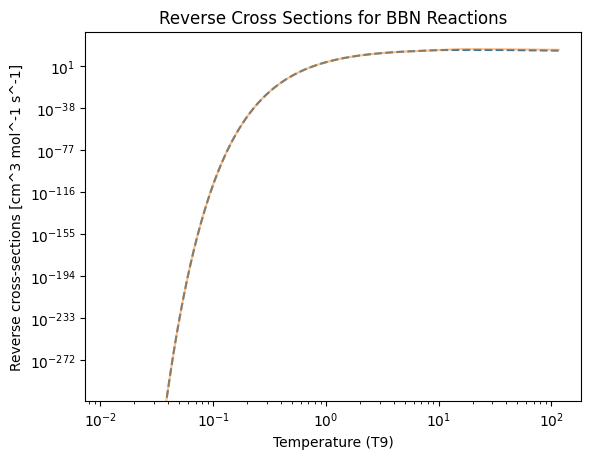

In [70]:
# Plotting the reverse rates for all the reactions

# plt.loglog(T9, df_rev['p+n->D+γ']/rhob, label='p + n -> D + γ (Digitized)', linestyle='--', alpha=1)
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "p+n->D+gamma"), label='p + n -> D + γ (Reverse)', alpha=0.5)


# plt.loglog(T9, df_rev['D+p->He3+γ']/rhob, label='D + p -> He3 + γ (Digitized)', linestyle='--', alpha=1)
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "D+p->He3+gamma"), label='D + p -> He3 + γ (Reverse)', alpha=0.5)


# plt.loglog(T9, df_rev['D+D->n+He3']/rhob, label='D + D -> He3 + n (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "D+D->He3+n"), label='D + D -> He3 + n (Reverse)', alpha=0.5)


# plt.loglog(T9, df_rev['D+D->p+T']/rhob, label='D + D -> p + T (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "D+D->p+T"), label='D + D -> p + T (Reverse)', alpha=0.5)

# plt.loglog(T9, df_rev['He3+n->p+T']/rhob, label='He3 + n -> T + p (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "He3+n->T+p"), label='He3 + n -> T + p (Reverse)', alpha=0.5)

# plt.loglog(T9, df_rev['T+D->n+He4']/rhob, label='T + D -> n + He4 (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "T+D->n+He4"), label='T + D -> n + He4 (Reverse)', alpha=0.5)

# plt.loglog(T9, df_rev['He3+D->p+He4']/rhob, label='He3 + D -> p + He4 (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "He3+D->p+He4"), label='He3 + D -> p + He4 (Reverse)', alpha=0.5)

# plt.loglog(T9, df_rev['He3+He4->Be7+γ']/rhob, label='He3 + He4 -> γ + Be7 (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "He3+He4->gamma+Be7"), label='He3 + He4 -> γ + Be7 (Reverse)', alpha=0.5)

# plt.loglog(T9, df_rev['Li7+p->He4+He4']/rhob, label='Li7 + p -> He4 + He4 (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "Li7+p->He4+He4"), label='Li7 + p -> He4 + He4 (Reverse)', alpha=0.5)

# plt.loglog(T9, df_rev['Be7+n->p+Li7']/rhob, label='Be7 + n -> p + Li7 (Digitized)', linestyle='--')
# plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "Be7+n->p+Li7"), label='Be7 + n -> p + Li7 (Reverse)', alpha=0.5)

plt.loglog(T9, df_rev['T+He4->Li7+γ']/rhob, label='T + He4 -> γ + Li7 (Digitized)', linestyle='--')
plt.loglog(T9, reverse_crosssection(K9toMeV(T9), "T+He4->gamma+Li7"), label='T + He4 -> γ + Li7 (Reverse)', alpha=0.5)


# plt.xlim(1e0, 8e0)
# plt.ylim(1e-8, 1e10)

plt.xlabel('Temperature (T9)')
plt.ylabel('Reverse cross-sections [cm^3 mol^-1 s^-1]')
plt.title('Reverse Cross Sections for BBN Reactions')

In [71]:
# interpolation fucntion wrt time

Tnu9 = MeVtoK9(Tnu)
weak_np = lambda_n2p
weak_pn = lambda_p2n

interpolation = sp.interpolate.interp1d(t, [T9, weak_np, weak_pn], 'cubic',fill_value='extrapolate') 



def BBN(t, state): 

    '''
    This function calculates the evolution of the abundances of all the elements 
    during BBN. 

    Input: Temperature (MeV), state vector containing [t, Tnu, Y_n, Y_p, Y_D, Y_T, X_He3, X_He4, X_Li7, X_Be7]
    Output: Derivatives of the state vector with respect to temperature
    '''

    Y_n, Y_p, Y_D, Y_T, Y_He3, Y_He4, Y_Li7, Y_Be7 = state

    T9, n2p, p2n = interpolation(t)

    T = K9toMeV(T9)


    # Some constants 

    Y = {
        "n": Y_n,
        "p": Y_p,
        "D": Y_D,
        "T": Y_T,
        "He3": Y_He3,
        "He4": Y_He4,
        "Li7": Y_Li7,
        "Be7": Y_Be7,
        "gamma": 1
    }

    rhob = h * T9**3
    # lambda_n2p = WeakRate(T, Tnu)[0]
    # lambda_p2n = WeakRate(T, Tnu)[1]


    def DiffRates(reaction, element):

        if reaction not in Rxn_dict.keys():
            raise ValueError(f"Reaction '{reaction}' not found in Rxn_dict. Please check the reaction name and ensure it is correctly defined in the dictionary.")


        reactants = reaction.split("->")[0].split("+")
        products = reaction.split("->")[1].split("+")

        r1, r2 = reactants
        p1, p2 = products

        if element in reactants: 

            dr_dt = (
                -(Y[r1] * Y[r2])/(1 + delta(r1, r2)) * crosssection(T, reaction) * rhob
                +(Y[p1] * Y[p2])/(1 + delta(p1, p2)) * reverse_crosssection(T, reaction) * rhob
            )
            
        elif element in products: 
            
            dr_dt = (
                (Y[r1] * Y[r2])/(1 + delta(r1, r2)) * crosssection(T, reaction) * rhob 
                -(Y[p1] * Y[p2])/(1 + delta(p1, p2)) * reverse_crosssection(T, reaction) * rhob
            )

        else: 
            raise ValueError(f"Element '{element}' not found in reactants or products of reaction '{reaction}'.")

        return dr_dt



    # Differential Equations

    # dt_dT = T_dependence(T, [t, Tnu])[0]

    # dTnu_dT = T_dependence(T, [t, Tnu])[1]

    dn_dt = (
        p2n * Y_p - n2p * Y_n +
        DiffRates("p+n->D+gamma", "n") +
        DiffRates("D+D->He3+n", "n") +
        DiffRates("He3+n->T+p", "n") +
        DiffRates("T+D->n+He4", "n") +
        DiffRates("Be7+n->p+Li7", "n")
        )

    dp_dt = (
        n2p * Y_n - p2n * Y_p +
        DiffRates("p+n->D+gamma", "p") +
        DiffRates("D+p->He3+gamma", "p") +
        DiffRates("D+D->p+T", "p") +
        DiffRates("He3+n->T+p", "p") +
        DiffRates("He3+D->p+He4", "p") +
        DiffRates("Be7+n->p+Li7", "p")+
        DiffRates("Li7+p->He4+He4", "p")
        )

    dD_dt = (
        DiffRates("p+n->D+gamma", "D") +
        DiffRates("D+p->He3+gamma", "D") +
        DiffRates("D+D->He3+n", "D") +
        DiffRates("D+D->p+T", "D") +
        DiffRates("T+D->n+He4", "D") +
        DiffRates("He3+D->p+He4", "D")
        )

    dT_dt = (
        DiffRates("D+D->p+T", "T") +
        DiffRates("He3+n->T+p", "T") +
        DiffRates("T+D->n+He4", "T") +
        DiffRates("T+He4->gamma+Li7", "T")
        )

    dHe3_dt = (
        DiffRates("D+p->He3+gamma", "He3") +
        DiffRates("D+D->He3+n", "He3") +
        DiffRates("He3+n->T+p", "He3") +
        DiffRates("He3+D->p+He4", "He3") +
        DiffRates("He3+He4->gamma+Be7", "He3")
        )

    dHe4_dt = (
        DiffRates("T+D->n+He4", "He4") +
        DiffRates("He3+D->p+He4", "He4") +
        DiffRates("He3+He4->gamma+Be7", "He4") +
        DiffRates("T+He4->gamma+Li7", "He4") +
        DiffRates("Li7+p->He4+He4", "He4")
        )

    dLi7_dt = (
        DiffRates("T+He4->gamma+Li7", "Li7") +
        DiffRates("Be7+n->p+Li7", "Li7") +
        DiffRates("Li7+p->He4+He4", "Li7")
        )

    dBe7_dt = (
        DiffRates("He3+He4->gamma+Be7", "Be7") +
        DiffRates("Be7+n->p+Li7", "Be7")
        )

    # Converting all the derivatives to be with respect to temperature instead of time using the chain rule 

    # dn_dT = dn_dt * dt_dT
    # dp_dT = dp_dt * dt_dT
    # dD_dT = dD_dt * dt_dT
    # dT_dT = dT_dt * dt_dT
    # dHe3_dT = dHe3_dt * dt_dT
    # dHe4_dT = dHe4_dt * dt_dT
    # dLi7_dT = dLi7_dt * dt_dT
    # dBe7_dT = dBe7_dt * dt_dT

    return [dn_dt, dp_dt, dD_dt, dT_dt, dHe3_dt, dHe4_dt, dLi7_dt, dBe7_dt]


In [72]:
# def BBN(T, state): 

#     '''
#     This function calculates the evolution of the abundances of all the elements 
#     during BBN. 

#     Input: Temperature (MeV), state vector containing [t, Tnu, Y_n, Y_p, Y_D, Y_T, X_He3, X_He4, X_Li7, X_Be7]
#     Output: Derivatives of the state vector with respect to temperature
#     '''

#     t, Tnu, Y_n, Y_p, Y_D, Y_T, Y_He3, Y_He4, Y_Li7, Y_Be7 = state


#     # Stopping excess temperature
    
#     # if MeVtoK9(T) >= 10: 
#     #     T = K9toMeV(10)  # Set T to 10^10 K in MeV


#     # Some constants 

#     Y = {
#         "n": Y_n,
#         "p": Y_p,
#         "D": Y_D,
#         "T": Y_T,
#         "He3": Y_He3,
#         "He4": Y_He4,
#         "Li7": Y_Li7,
#         "Be7": Y_Be7,
#         "gamma": 1
#     }

#     rhob = h * MeVtoK9(T)**3
#     lambda_n2p = WeakRate(T, Tnu)[0]
#     lambda_p2n = WeakRate(T, Tnu)[1]


#     def DiffRates(reaction, element):

#         if reaction not in Rxn_dict.keys():
#             raise ValueError(f"Reaction '{reaction}' not found in Rxn_dict. Please check the reaction name and ensure it is correctly defined in the dictionary.")


#         reactants = reaction.split("->")[0].split("+")
#         products = reaction.split("->")[1].split("+")

#         r1, r2 = reactants
#         p1, p2 = products

#         if element in reactants: 

#             dr_dt = (
#                 # -(Y[r1] * Y[r2])/(1 + delta(r1, r2)) * crosssection(T, Rxn_dict[reaction]["a_forward"]) * rhob 
#                 -(Y[r1] * Y[r2])/(1 + delta(r1, r2)) * crosssection(T, reaction) * rhob
#                 # +(Y[p1] * Y[p2])/(1 + delta(p1, p2)) * crosssection(T, Rxn_dict[reaction]["a_reverse"]) * rhob
#                 +(Y[p1] * Y[p2])/(1 + delta(p1, p2)) * reverse_crosssection(T, reaction) * rhob
#             )
            
#         elif element in products: 
            
#             dr_dt = (
#                 # (Y[r1] * Y[r2])/(1 + delta(r1, r2)) * crosssection(T, Rxn_dict[reaction]["a_forward"]) * rhob 
#                 (Y[r1] * Y[r2])/(1 + delta(r1, r2)) * crosssection(T, reaction) * rhob 
#                 # -(Y[p1] * Y[p2])/(1 + delta(p1, p2)) * crosssection(T, Rxn_dict[reaction]["a_reverse"]) * rhob
#                 -(Y[p1] * Y[p2])/(1 + delta(p1, p2)) * reverse_crosssection(T, reaction) * rhob
#             )

#         else: 
#             raise ValueError(f"Element '{element}' not found in reactants or products of reaction '{reaction}'.")

#         return dr_dt



#     # Differential Equations

#     dt_dT = T_dependence(T, [t, Tnu])[0]

#     dTnu_dT = T_dependence(T, [t, Tnu])[1]

#     dn_dt = (
#         lambda_p2n * Y_p - lambda_n2p * Y_n +
#         DiffRates("p+n->D+gamma", "n") +
#         DiffRates("D+D->He3+n", "n") +
#         DiffRates("He3+n->T+p", "n") +
#         DiffRates("T+D->n+He4", "n") +
#         DiffRates("Be7+n->p+Li7", "n")
#         )

#     dp_dt = (
#         lambda_n2p * Y_n - lambda_p2n * Y_p +
#         DiffRates("p+n->D+gamma", "p") +
#         DiffRates("D+p->He3+gamma", "p") +
#         DiffRates("D+D->p+T", "p") +
#         DiffRates("He3+n->T+p", "p") +
#         DiffRates("He3+D->p+He4", "p") +
#         DiffRates("Be7+n->p+Li7", "p")+
#         DiffRates("Li7+p->He4+He4", "p")
#         )

#     dD_dt = (
#         DiffRates("p+n->D+gamma", "D") +
#         DiffRates("D+p->He3+gamma", "D") +
#         DiffRates("D+D->He3+n", "D") +
#         DiffRates("D+D->p+T", "D") +
#         DiffRates("T+D->n+He4", "D") +
#         DiffRates("He3+D->p+He4", "D")
#         )

#     dT_dt = (
#         DiffRates("D+D->p+T", "T") +
#         DiffRates("He3+n->T+p", "T") +
#         DiffRates("T+D->n+He4", "T") +
#         DiffRates("T+He4->gamma+Li7", "T")
#         )

#     dHe3_dt = (
#         DiffRates("D+p->He3+gamma", "He3") +
#         DiffRates("D+D->He3+n", "He3") +
#         DiffRates("He3+n->T+p", "He3") +
#         DiffRates("He3+D->p+He4", "He3") +
#         DiffRates("He3+He4->gamma+Be7", "He3")
#         )

#     dHe4_dt = (
#         DiffRates("T+D->n+He4", "He4") +
#         DiffRates("He3+D->p+He4", "He4") +
#         DiffRates("He3+He4->gamma+Be7", "He4") +
#         DiffRates("T+He4->gamma+Li7", "He4") +
#         DiffRates("Li7+p->He4+He4", "He4")
#         )

#     dLi7_dt = (
#         DiffRates("T+He4->gamma+Li7", "Li7") +
#         DiffRates("Be7+n->p+Li7", "Li7") +
#         DiffRates("Li7+p->He4+He4", "Li7")
#         )

#     dBe7_dt = (
#         DiffRates("He3+He4->gamma+Be7", "Be7") +
#         DiffRates("Be7+n->p+Li7", "Be7")
#         )

#     # Converting all the derivatives to be with respect to temperature instead of time using the chain rule 

#     dn_dT = dn_dt * dt_dT
#     dp_dT = dp_dt * dt_dT
#     dD_dT = dD_dt * dt_dT
#     dT_dT = dT_dt * dt_dT
#     dHe3_dT = dHe3_dt * dt_dT
#     dHe4_dT = dHe4_dt * dt_dT
#     dLi7_dT = dLi7_dt * dt_dT
#     dBe7_dT = dBe7_dt * dt_dT

#     return [dt_dT, dTnu_dT, dn_dT, dp_dT, dD_dT, dT_dT, dHe3_dT, dHe4_dT, dLi7_dT, dBe7_dT]


In [73]:
BBN(t[0], [Y_initial["n"], Y_initial["p"], Y_initial["D"], Y_initial["T"], Y_initial["He3"], Y_initial["He4"], Y_initial["Li7"], Y_initial["Be7"]])

[np.float64(450.3875355106502),
 np.float64(450.3875355108716),
 np.float64(-450.38753551040696),
 np.float64(-3.768279320620318e-15),
 np.float64(-2.3596495948503804e-10),
 np.float64(-9.826668475746572e-29),
 np.float64(3.55534421894574e-55),
 np.float64(1.9417655347255906e-56)]

In [74]:
# Setting up the initial conditions for the ODE solver

# initial_conditions = [
#     0,  # Initial time (t)
#     Tnu[0],  # Initial neutrino temperature (Tnu)
#     Y_initial["n"],  # Initial neutron abundance (Y_n)
#     Y_initial["p"],  # Initial proton abundance (Y_p)
#     Y_initial["D"],  # Initial deuterium abundance (Y_D)
#     Y_initial["T"],  # Initial tritium abundance (Y_T)
#     Y_initial["He3"],  # Initial helium-3 abundance (Y_He3)
#     Y_initial["He4"],  # Initial helium-4 abundance (Y_He4)
#     Y_initial["Li7"],  # Initial lithium-7 abundance (Y_Li7)
#     Y_initial["Be7"]   # Initial beryllium-7 abundance (Y_Be7)
# ]

initial_conditions = [
    Y_initial["n"],  # Initial neutron abundance (Y_n)
    Y_initial["p"],  # Initial proton abundance (Y_p)
    Y_initial["D"],  # Initial deuterium abundance (Y_D)
    Y_initial["T"],  # Initial tritium abundance (Y_T)
    Y_initial["He3"],  # Initial helium-3 abundance (Y_He3)
    Y_initial["He4"],  # Initial helium-4 abundance (Y_He4)
    Y_initial["Li7"],  # Initial lithium-7 abundance (Y_Li7)
    Y_initial["Be7"]   # Initial beryllium-7 abundance (Y_Be7)
]

# Solving the system of ODEs using solve_ivp

solution = sp.integrate.solve_ivp(
    fun= BBN,
    t_span= t[[0, -1]],
    y0= initial_conditions,
    t_eval= t,
    method= 'Radau',
    dense_output= True,
    rtol=1e-10,
    atol=1e-14
)

print(solution)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.340e-04 ...  1.296e+06  1.320e+06]
        y: [[ 4.677e-01  4.674e-01 ...  2.117e-15  1.956e-15]
            [ 5.323e-01  5.326e-01 ...  7.602e-01  7.602e-01]
            ...
            [ 6.180e-71  5.125e-71 ...  7.592e-11  7.592e-11]
            [ 5.994e-71  5.471e-71 ...  1.729e-10  1.729e-10]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7fedbfd32ad0>
 t_events: None
 y_events: None
     nfev: 28315
     njev: 958
      nlu: 2782


Final mass fraction of hydrogen (X[p]): 0.7601906060664446
Final number fraction of helium-4 (Y[He4]): 0.4755522421514404
Final mass fraction of Deuterium wrt hydrogen (X[D]/X[H]): 0.00010636505385794449
Final mass fraction of Tritium wrt hydrogen (X[T]/X[H]): 5.462149487347094e-07
Final mass fraction of helium-3 wrt hydrogen (X[He3]/X[H]): 4.5437006886235436e-05
Final mass fraction of lithium-7 wrt hydrogen (X[Li7]/X[H]): 6.990616311896953e-10
Final mass fraction of beryllium-7 wrt hydrogen (X[Be7]/X[H]): 1.5923404687090336e-09


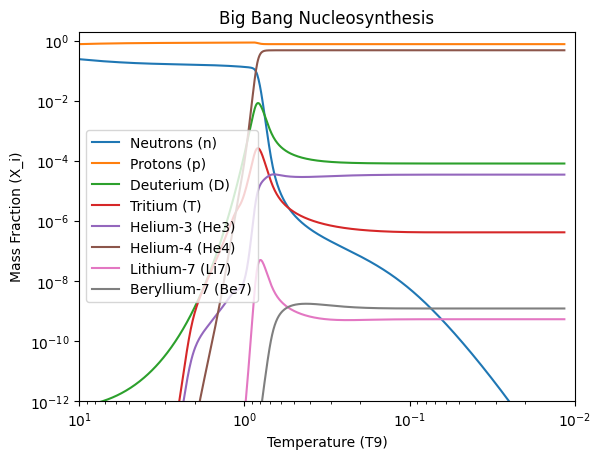

In [97]:
# Writing down the solutions 

t = solution.t
Y_n, Y_p, Y_D, Y_T, Y_He3, Y_He4, Y_Li7, Y_Be7 = solution.y

# Final abundances of the elements at the end of BBN

Y_final = {
    "n": Y_n[-1],
    "p": Y_p[-1],
    "D": Y_D[-1],
    "T": Y_T[-1],
    "He3": Y_He3[-1],
    "He4": Y_He4[-1],
    "Li7": Y_Li7[-1],
    "Be7": Y_Be7[-1]
}


# Printing the final abundances 

print("Final mass fraction of hydrogen (X[p]):", Y_final["p"])
print("Final number fraction of helium-4 (Y[He4]):", Y_final["He4"] * He4["A"])
print("Final mass fraction of Deuterium wrt hydrogen (X[D]/X[H]):", (Y_final["D"] * Deut["A"])/Y_final["p"])
print("Final mass fraction of Tritium wrt hydrogen (X[T]/X[H]):", (Y_final["T"] * Trit["A"])/Y_final["p"])
print("Final mass fraction of helium-3 wrt hydrogen (X[He3]/X[H]):", (Y_final["He3"] * He3["A"])/Y_final["p"])
print("Final mass fraction of lithium-7 wrt hydrogen (X[Li7]/X[H]):", (Y_final["Li7"] * Li7["A"])/Y_final["p"])
print("Final mass fraction of beryllium-7 wrt hydrogen (X[Be7]/X[H]):", (Y_final["Be7"] * Be7["A"])/Y_final["p"])


# Finding the temperature corresponding to the time

T9_plot = interpolation(t)[0]

# Plotting the evolution of the abundances of the elements during BBN

plt.loglog(T9_plot, Y_n, label='Neutrons (n)')
plt.loglog(T9_plot, Y_p, label='Protons (p)')
plt.loglog(T9_plot, Y_D * Deut["A"], label='Deuterium (D)')
plt.loglog(T9_plot, Y_T * Trit["A"], label='Tritium (T)')
plt.loglog(T9_plot, Y_He3 * He3["A"], label='Helium-3 (He3)')
plt.loglog(T9_plot, Y_He4 * He4["A"], label='Helium-4 (He4)')
plt.loglog(T9_plot, Y_Li7 * Li7["A"], label='Lithium-7 (Li7)')
plt.loglog(T9_plot, Y_Be7 * Be7["A"], label='Beryllium-7 (Be7)')

plt.xlim(1e1, 1e-2)
plt.ylim(1e-12, 1e0 * 2)
plt.xlabel('Temperature (T9)')
plt.ylabel('Mass Fraction (X_i)')
plt.title('Big Bang Nucleosynthesis')
plt.legend()
plt.show()


# Test


In [76]:
# K9toMeV(T9_subset)

In [77]:
# solution

In [78]:
# lambda_n2p

In [79]:
# ForwardRates = np.array([
#     crosssection(K9toMeV(T9), Rxn_dict["p+n->D+gamma"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["D+p->He3+gamma"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["D+D->He3+n"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["D+D->p+T"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["He3+n->T+p"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["T+D->n+He4"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["He3+D->p+He4"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["He3+He4->gamma+Be7"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["T+He4->gamma+Li7"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["Be7+n->p+Li7"]["a_forward"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["Li7+p->He4+He4"]["a_forward"]) * rhob
# ])

# ReverseRates= np.array([
#     crosssection(K9toMeV(T9), Rxn_dict["p+n->D+gamma"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["D+p->He3+gamma"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["D+D->He3+n"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["D+D->p+T"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["He3+n->T+p"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["T+D->n+He4"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["He3+D->p+He4"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["He3+He4->gamma+Be7"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["T+He4->gamma+Li7"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["Be7+n->p+Li7"]["a_reverse"]) * rhob,
#     crosssection(K9toMeV(T9), Rxn_dict["Li7+p->He4+He4"]["a_reverse"]) * rhob
# ])

In [80]:
# ForwardRates[0]

In [81]:
# # Pre-compute all strong rates over the full temperature grid
# # and create interpolators — mirrors the weak rate interpolation pattern

# T9_grid = MeVtoK9(T)
# rhob_grid = h * T9_grid**3

# F_precomputed = np.array([
#     crosssection(T, Rxn_dict["p+n->D+gamma"]["a_forward"])   * rhob_grid,
#     crosssection(T, Rxn_dict["D+p->He3+gamma"]["a_forward"]) * rhob_grid,
#     crosssection(T, Rxn_dict["D+D->He3+n"]["a_forward"])     * rhob_grid,
#     crosssection(T, Rxn_dict["D+D->p+T"]["a_forward"])       * rhob_grid,
#     crosssection(T, Rxn_dict["He3+n->T+p"]["a_forward"])     * rhob_grid,
#     crosssection(T, Rxn_dict["T+D->n+He4"]["a_forward"])     * rhob_grid,
#     crosssection(T, Rxn_dict["He3+D->p+He4"]["a_forward"])   * rhob_grid,
#     crosssection(T, Rxn_dict["He3+He4->gamma+Be7"]["a_forward"]) * rhob_grid,
#     crosssection(T, Rxn_dict["T+He4->gamma+Li7"]["a_forward"])   * rhob_grid,
#     crosssection(T, Rxn_dict["Be7+n->p+Li7"]["a_forward"])   * rhob_grid,
#     crosssection(T, Rxn_dict["Li7+p->He4+He4"]["a_forward"]) * rhob_grid,
# ])

# R_precomputed = np.array([
#     crosssection(T, Rxn_dict["p+n->D+gamma"]["a_reverse"])   * rhob_grid,
#     crosssection(T, Rxn_dict["D+p->He3+gamma"]["a_reverse"]) * rhob_grid,
#     crosssection(T, Rxn_dict["D+D->He3+n"]["a_reverse"])     * rhob_grid,
#     crosssection(T, Rxn_dict["D+D->p+T"]["a_reverse"])       * rhob_grid,
#     crosssection(T, Rxn_dict["He3+n->T+p"]["a_reverse"])     * rhob_grid,
#     crosssection(T, Rxn_dict["T+D->n+He4"]["a_reverse"])     * rhob_grid,
#     crosssection(T, Rxn_dict["He3+D->p+He4"]["a_reverse"])   * rhob_grid,
#     crosssection(T, Rxn_dict["He3+He4->gamma+Be7"]["a_reverse"]) * rhob_grid,
#     crosssection(T, Rxn_dict["T+He4->gamma+Li7"]["a_reverse"])   * rhob_grid,
#     crosssection(T, Rxn_dict["Be7+n->p+Li7"]["a_reverse"])   * rhob_grid,
#     crosssection(T, Rxn_dict["Li7+p->He4+He4"]["a_reverse"]) * rhob_grid,
# ])

# # Create interpolators (same pattern as the weak rate interpolation)
# strong_rate_interp = sp.interpolate.interp1d(
#     t, np.vstack([F_precomputed, R_precomputed]), 'cubic', fill_value='extrapolate'
# )

In [82]:
# crosssection(K9toMeV(10), Rxn_dict["p+n->D+gamma"]["a_forward"])

In [83]:
# strong_rate_interp(t[1])[:11]

In [84]:
# interpolation(1)

In [85]:
# ### REACTION NETWORK ###

# import numpy


# weak_np = lambda_n2p
# weak_pn = lambda_p2n

# T9 = MeVtoK9(T)
# Tnu9 = MeVtoK9(Tnu)

# rhob = h * T9**3

# # Allows us to call functions within this function.
# interpolation = sp.interpolate.interp1d(t, [T9, Tnu9, weak_np, weak_pn], 'cubic',fill_value='extrapolate') 

# # Equation 45:
# def BBN(t,Y):
    
#     Yp, Yn, YD, YT, YHe3, YHe4, YBe7, YLi7 = Y

#     T9i,Tnu9i,np_,pn = interpolation(t)

#     F = numpy.zeros(11)

#     # F = ForwardRates
#     # R = ReverseRates

#     rhob = h * T9i**3

#     # Single call instead of 22 crosssection() evaluations
#     rates = strong_rate_interp(t)
#     F = rates[:11]
#     R = rates[11:]


#     # F = numpy.array([
#     #     crosssection(K9toMeV(T9i), Rxn_dict["p+n->D+gamma"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["D+p->He3+gamma"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["D+D->He3+n"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["D+D->p+T"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["He3+n->T+p"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["T+D->n+He4"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["He3+D->p+He4"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["He3+He4->gamma+Be7"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["T+He4->gamma+Li7"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["Be7+n->p+Li7"]["a_forward"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["Li7+p->He4+He4"]["a_forward"]) * rhob
#     # ])

#     # R = numpy.array([
#     #     crosssection(K9toMeV(T9i), Rxn_dict["p+n->D+gamma"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["D+p->He3+gamma"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["D+D->He3+n"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["D+D->p+T"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["He3+n->T+p"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["T+D->n+He4"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["He3+D->p+He4"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["He3+He4->gamma+Be7"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["T+He4->gamma+Li7"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["Be7+n->p+Li7"]["a_reverse"]) * rhob,
#     #     crosssection(K9toMeV(T9i), Rxn_dict["Li7+p->He4+He4"]["a_reverse"]) * rhob
#     # ])

#     #1. p + n <--> D + γ

#     #2. D + p <--> He3 + γ
 
#     #3. D + D <--> n + He3

#     #4. D + D <--> p + T

#     #5. He3 + n <--> p + T

#     #6. T + D <--> n + He4

#     #7. He3 + D <--> p + He4

#     #8. He3 + He4 <--> Be7 + γ

#     #9. T + He4 <--> Li7 + γ

#     #10. Be7 + n <--> p + Li7

#     #11. Li7 + p <--> He4 + He4
    
#     dYpF = -pn*Yp + np_*Yn - F[0]*Yp*Yn - F[1]*Yp*YD + (1/2)*F[3]*YD**2 + F[4]*YHe3*Yn + F[6]*YHe3*YD + F[9]*YBe7*Yn - F[10]*YLi7*Yp
#     dYnF = -np_*Yn + pn*Yp - F[0]*Yp*Yn +  (1/2) * F[2]*YD**2 - F[4]*YHe3*Yn + F[5]*YT*YD - F[9]*YBe7*Yn
#     dYDF = F[0]*Yp*Yn - F[1]*Yp*YD - F[2]*YD**2 - F[3]*YD**2 - F[5]*YT*YD - F[6]*YHe3*YD
#     dYTF = (1/2)* F[3]*YD**2 + F[4]*YHe3*Yn - F[5]*YT*YD - F[8]*YT*YHe4
#     dYHe3F = F[1]*Yp*YD +  (1/2)*F[2]*YD**2 - F[4]*YHe3*Yn - F[6]*YHe3*YD - F[7]*YHe4*YHe3
#     dYHe4F = F[5]*YT*YD + F[6]*YHe3*YD - F[7]*YHe4*YHe3 - F[8]*YT*YHe4 + F[10]*YLi7*Yp
#     dYBe7F = F[7]*YHe4*YHe3 - F[9]*YBe7*Yn
#     dYLi7F = F[8]*YT*YHe4 + F[9]*YBe7*Yn - (1/2)*F[10]*YLi7*Yp 

#     dYpR = R[0]*YD + R[1]*YHe3 - R[3]*Yp*YT - R[4]*Yp*YT - R[6]*YHe4*Yp - R[9]*YLi7*Yp + (1/2) * R[10]*YHe4**2
#     dYnR = R[0]*YD - R[2]*YHe3*Yn + R[4]*Yp*YT - R[5]*YHe4*Yn + R[9]*YLi7*Yp
#     dYDR = -R[0]*YD + R[1]*YHe3 + 2*R[2]*YHe3*Yn + 2*R[3]*Yp*YT + R[5]*YHe4*Yp + R[6]*YHe4*Yp
#     dYTR = - R[3]*Yp*YT - R[4]*Yp*YT + R[5]*YHe4*Yp + R[8]*YLi7
#     dYHe3R = -R[1]*YHe3 - R[2]*YHe3*Yn + R[4]*Yp*YT + R[6]*YHe4*Yp + R[7]*YBe7
#     dYHe4R = -R[5]*YHe4*Yn - R[6]*YHe4*Yp + R[7]*YBe7 + R[8]*YLi7 -  R[10]*YHe4**2
#     dYBe7R = -R[7]*YBe7 + R[9]*YLi7*Yp
#     dYLi7R = -R[8]*YLi7 - R[9]*YLi7*Yp +  (1/2) * R[10]*YHe4**2 

#     dYp = dYpF + dYpR
#     dYn = dYnF + dYnR
#     dYD = dYDF + dYDR
#     dYT = dYTF+dYTR
#     dYHe3 = dYHe3F + dYHe3R
#     dYHe4 = dYHe4F + dYHe4R
#     dYBe7 = dYBe7F + dYBe7R
#     dYLi7 = dYLi7F + dYLi7R

#     return dYp, dYn, dYD, dYT, dYHe3, dYHe4, dYBe7, dYLi7

In [86]:
# Y0 = [
#     Y_initial["p"],  # Initial proton abundance (Y_p)
#     Y_initial["n"],  # Initial neutron abundance (Y_n)
#     Y_initial["D"],  # Initial deuterium abundance (Y_D)
#     Y_initial["T"],  # Initial tritium abundance (Y_T)
#     Y_initial["He3"],  # Initial helium-3 abundance (Y_He3)
#     Y_initial["He4"],  # Initial helium-4 abundance (Y_He4)
#     Y_initial["Be7"],  # Initial beryllium-7 abundance (Y_Be7)
#     Y_initial["Li7"]   # Initial lithium-7 abundance (Y_Li7)
# ]

# BBN(t[0], Y0)

In [87]:
# crosssection(K9toMeV(T9), Rxn_dict["p+n->D+gamma"]["a_forward"]) * rhob

In [88]:
# Ti

In [89]:
# t_subset = t[t >= 0.4]

In [90]:
# ### SOLVING THE ODE ###
# Y = sp.integrate.solve_ivp(BBN, [t_subset[0], t_subset[-1]], Y0,t_eval=t_subset, dense_output=True, method='Radau',rtol=1e-12,atol=1e-15)
# print(Y)

In [91]:
# t[-1]

In [92]:
# # Making a subset of T9 and t such that t goes from the value 1 to t[-1]
# t_subset = t[t >= 0.5]

# # corresponding subset of T9 

# T9_subset = MeVtoK9(T[t >= 0.5])

In [93]:
# K9toMeV(T9_subset[0])

In [94]:
# weights = np.array([1,1,2,3,3,4,7,7])

# ## Initialize the figure and axis
# fig = plt.figure(figsize=(15,10), dpi=400)
# ax = plt.subplot(111)
# ax.grid()

# colors = ['black', '#e31a1c', 'cornflowerblue', 'sienna', '#33a02c', 'blueviolet', 'mediumvioletred', '#ff7f00', '#cab2d6']
# ## Plot
# for n in range(8):
#     ax.loglog(T9_subset, (solution.y[n])*weights[n], c=colors[n])

# ## Legend
# labels = [r'$\rm p \, (H)$', 'n', r'$\rm D \, (^2 H)$', r'$\rm T \, (^3 H)$', r'$\rm ^3He$', r'$\rm Y_p \, (^4 He)$', r'$\rm ^7Be$', r'$\rm ^7Li$']


# box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(labels, loc='center left', bbox_to_anchor=(1,0.5), fontsize=30)

# ax.set_xlim(1e1,MeVtoK9(1e-2)); 
# #ax.set_xlim(1e0,1e-2)
# ax.set_ylim(1e-12,2e0)


# ax.tick_params(axis='both', direction='in', which='major', length = 20, width=1.15, right=True, labelsize=36, pad=8)
# ax.tick_params(axis='x', direction='in', length=10, width=0.8, right=True, which='minor')
# ax.tick_params(axis='y', direction='in', length=20, width=0.6, right=True,  which='minor', labelsize=15)

# # ax.xaxis.set_minor_locator(LogLocator())
# # ax.yaxis.set_minor_locator(LogLocator())
# # ax.xaxis.set_minor_formatter(LogFormatterSciNotation())
# # ax.yaxis.set_minor_formatter(LogFormatterSciNotation())
# ax.minorticks_on()

# ## Labels
# ax.set_ylabel('Mass Fraction', fontsize=36)
# ax.set_xlabel(r'Temperature ($\rm{10^9 K}$)', fontsize=36);

# textlabels = ['p','n','D','T','3','4','Be','Li']
# print(f'The final mass fraction of Hydrogen (protons) is {weights[0]*(Y.y[0][-1]) : 0.5g}')
# print(f'The final mass fraction of Helium 4 (Yp) is {(Y.y[5][-1]) *weights[5]: 0.5g}')
# print(f'The final percentage of mass fraction of the sum Li+Be is',f' {(Y.y[6][-1] + Y.y[7][-1] )/Y.y[0][-1] : 0.4g}')
# print('----------------------------- \n')
# for n in [1,2,3,4,6,7]:
#     print(f'The final percentage of mass fraction of',textlabels[n],f'is {(Y.y[n][-1])/Y.y[0][-1]:0.4g}')
# sum = 0 
# for n in range(8):
#     sum += Y.y[n][-1]*weights[n] 
    
# print(f'The total sum of elements is: {sum*100:0.0f} %.')
# fig.savefig('figures/bbn_abundances.pdf', dpi=400, bbox_inches='tight')